<a href="https://colab.research.google.com/github/DrFaus/Estadistica2026B/blob/main/DiseniosExperimentalesUnFactor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diseños experimentales

En inferencial vieron un tema que será muy importante en esta unidad. La diferencia de medias mediante la distribución t de student. En esa parte de su formación, se les daba el experimento ya definido y había que determinar si había diferencia significativa entre tratamientos. Abordemos esto mediante un ejemplo.

Se desea evaluar el efecto de distintos métodos de estudio sobre el desempeño académico de los estudiantes en un curso. En particular, se comparan tres estrategias de preparación para un examen:

+ Método 1: estudio tradicional basado en apuntes y lectura teórica,
+ Método 2: estudio apoyado en guías de ejercicios resueltos,
+ Método 3: estudio con guías de ejercicios y evaluaciones cortas de retroalimentación.

Para la realización del experimento, se seleccionaron 15 estudiantes de cada uno de los tres grupos académicos (A, B y C), obteniendo un total de 45 participantes.

Dentro de cada grupo, los estudiantes fueron asignados a los tres métodos de estudio, de manera que cada método contó con 5 estudiantes por grupo. En consecuencia, cada tratamiento presenta el mismo número de observaciones dentro de cada bloque.

La justificación de esta estructura experimental se abordará más adelante.

La variable de interés es la calificación obtenida en el examen, medida en una escala numérica.

Los datos obtenidos se presentan en la siguiente tabla:

| Grupo  | Método 1 | Método 2 | Método 3 |
| ------ | -------: | -------: | -------: |
| A      |       64 |       71 |       77 |
| A      |       66 |       72 |       79 |
| A      |       65 |       73 |       76 |
| A      |       67 |       74 |       80 |
| A      |       68 |       73 |       81 |
| B      |       68 |       75 |       81 |
| B      |       70 |       76 |       83 |
| B      |       69 |       74 |       82 |
| B      |       71 |       78 |       84 |
| B      |       72 |       77 |       85 |
| C      |       72 |       79 |       85 |
| C      |       74 |       81 |       87 |
| C      |       73 |       80 |       86 |
| C      |       75 |       82 |       88 |
| C      |       76 |       83 |       89 |




## Diferencia de medias con t de student

En el curso de Estadística Inferencial I, se estudió que la comparación entre dos tratamientos puede realizarse mediante un procedimiento basado en la diferencia de medias, utilizando herramientas estadísticas como la prueba t de Student.

En este punto, es posible que surja la duda sobre qué se considera un tratamiento en este contexto, o incluso si sería válido comparar, por ejemplo, la media del grupo A con la del grupo B.

Es importante aclarar que un tratamiento corresponde a la condición o intervención que se aplica a las unidades experimentales con el propósito de generar un efecto en la variable de interés. En este caso, los tratamientos son los distintos métodos de estudio.

Si el objetivo del estudio fuera comparar el desempeño entre grupos (por ejemplo, determinar si el grupo A es mejor que el grupo B), entonces los grupos podrían considerarse como tratamientos. Sin embargo, en este experimento el objetivo es evaluar qué método de estudio produce mejores resultados en los estudiantes.

Por lo tanto, los tratamientos de interés son: Método 1, Método 2 y Método 3.

Por el momento, nos enfocaremos en comparar únicamente el Método 1 y el Método 2 mediante una prueba de hipótesis basada en la diferencia de medias.

In [ ]:
import pandas as pd

metodo_1 = pd.Series([64, 66, 65, 67, 68,
            68, 70, 69, 71, 72,
            72, 74, 73, 75, 76])

metodo_2 = pd.Series([71, 72, 73, 74, 73,
            75, 76, 74, 78, 77,
            79, 81, 80, 82, 83])

Lo primero que se debe hacer, es comprobar que ambos conjuntos sigan una distribución normal. Para esto, ya contamos con un código que nos puede ayudar. Aplicamos test de Shapiro a cada conjunto.

valor-p (Shapiro) = 0.8856781355272578


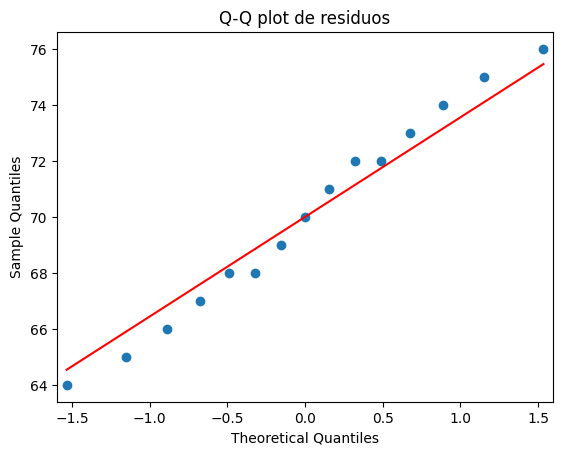

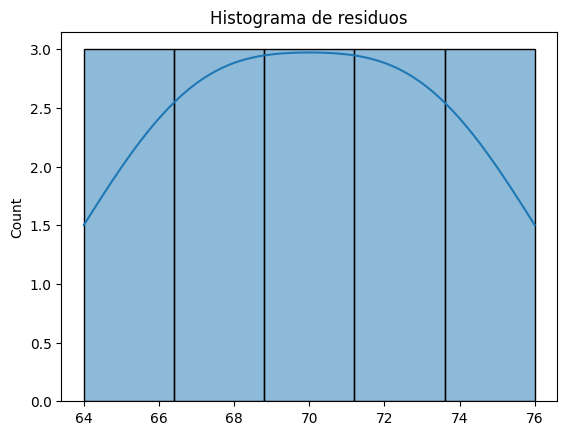

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(metodo_1)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(metodo_1, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(metodo_1, kde=True)
plt.title("Histograma de residuos")
plt.show()

valor-p (Shapiro) = 0.5257214760823039


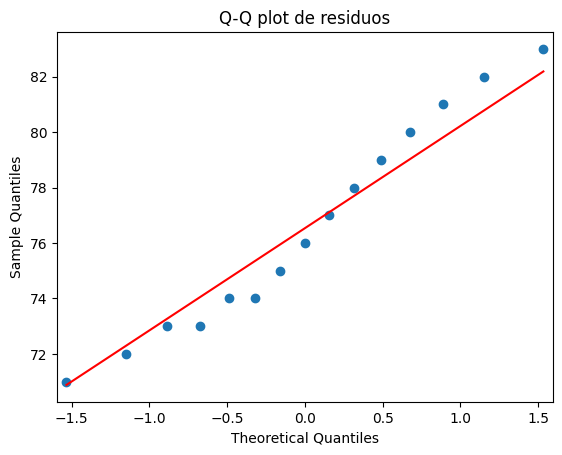

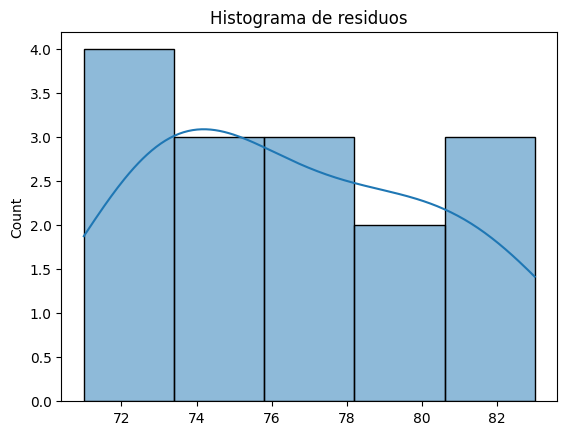

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(metodo_2)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(metodo_2, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(metodo_2, kde=True)
plt.title("Histograma de residuos")
plt.show()

Tras aplicar el test de Shapiro a cada conjunto, comprobamos que cumple con el criterio de normalidad. Este criterio es fundamental para utilizar la distribución t de student. De aquí en adelante, hay dos formas de proceder, dependiendo de si hay o no homoscedasticidad, para lo que se utiliza la prueba F. El estadístico $F$ se calcula de la siguiente manera:

$$ F = \frac{s^2_1}{s^2_2} $$

la varianza muestral de cada método se puede obtener mediante el método `.var()`, como sigue:

In [ ]:
# Estadístico F
F = metodo_1.var() / metodo_2.var()

F

0.9325916230366491

Los grados de libertad para cada método se calculan mediante:

In [ ]:
gl_m_1 = metodo_1.size - 1
gl_m_2 = metodo_2.size - 1

Y a continuación el valor-p junto a la prueba de hipótesis:

In [ ]:
print("H₀: σ₁² = σ₂² (varianzas iguales)")
print("H₁: σ₁² ≠ σ₂² (varianzas diferentes)")
print("α: 0.05")

import numpy as np
from scipy.stats import f

valor_p = f.cdf(F, gl_m_1, gl_m_2) # cola izquierda

print(f"F = {F:.4f}")
print(f"valor-p = {valor_p:.4f}")

H₀: σ₁² = σ₂² (varianzas iguales)
H₁: σ₁² ≠ σ₂² (varianzas diferentes)
α: 0.05
F = 0.9326
valor-p = 0.4490


Por lo que se acepta la homoscedasticidad. El siguiente paso era estimar la desviación estándar conjunta, calcular el estadístico t y hacer la prueba de hipótesis. En Python, hay una función que hace todo esto por nosotros, sólo hay que señalar si hay homoscedasticidad o no mediante el argumento `equal_var`. Declaramos que hay igualdad de varianzas dado que fue el resultado de la prueba F `equal_var = True`, y realizamos la prueba:

In [ ]:
print("H₀: μ₁ - μ₂ = 0")
print("H₁: μ₁ - μ₂ ≠ 0")
print("α: 0.001")

from scipy.stats import ttest_ind

t, valor_p = ttest_ind(metodo_1, metodo_2, equal_var=True, alternative = 'two-sided') # dos colas

print(f"t = {t:.4f}")
print(f"valor-p (bilateral) = {valor_p:.8f}")

H₀: μ₁ - μ₂ = 0
H₁: μ₁ - μ₂ ≠ 0
α: 0.001
t = -4.7714
valor-p (bilateral) = 0.00005182


Con este análisis se concluiría que existe una diferencia significativa entre los dos métodos. Sin embargo, en este contexto, aplicar ese procedimiento sería **INCORRECTO**.

Debe quedar muy claro lo siguiente:

**CUANDO EN UN ESTUDIO HAY MÁS DE DOS TRATAMIENTOS, NO DEBE UTILIZARSE LA PRUEBA t DE STUDENT PARA COMPARARLOS MEDIANTE MÚLTIPLES PRUEBAS DE HIPÓTESIS POR PARES.**

Este punto es fundamental. En la práctica, es más común de lo que parece encontrar trabajos, incluso de personas ya tituladas, en los que se comete este error. Y no se trata de un detalle menor: una decisión estadística incorrecta puede afectar seriamente la validez de los resultados y, en consecuencia, comprometer todo un proyecto.

La forma adecuada de abordar este tipo de problema es mediante el Análisis de Varianza (ANOVA). Esta técnica permite comparar simultáneamente las medias de más de dos tratamientos, controlando el error tipo I que se incrementaría al realizar múltiples pruebas t de manera independiente.

En general, ANOVA es el método apropiado cuando se desea evaluar si existen diferencias significativas entre tres o más tratamientos dentro de un mismo experimento.

La prueba t es muy robusta y da más libertad sobre la hipótesis alternativa. Con la prueba t se puede elegir:

+ $H_1$: $\mu_1 - \mu_2 \lt 0$
+ $H_1$: $\mu_1 - \mu_2 \ne 0$
+ $H_1$: $\mu_1 - \mu_2 \gt 0$

En cambio con ANOVA de dos tratamientos siempre será:

+ $H_1$: $\mu_1 - \mu_2 \ne 0$

Volviendo al problema, la forma más simple de abordar 3 tratamientos es mediante un diseño completamente aleatorio.

## Diseño Completamente Aleatorio (DCA)

Cuando las unidades experimentales se consideran homogéneas y los tratamientos se asignan completamente al azar, el diseño experimental se denomina Diseño Completamente al Azar (DCA).

Este tipo de diseño puede utilizarse con dos o más tratamientos; sin embargo, cuando el número de tratamientos es mayor a dos, el análisis adecuado para comparar sus medias es el Análisis de Varianza (ANOVA).

La tabla que contiene los datos tiene la siguiente estructura:

| Grupo  | Método 1 | Método 2 | Método 3 |
| ------ | -------: | -------: | -------: |
| A      |       64 |       71 |       77 |
| A      |       66 |       72 |       79 |
| A      |       65 |       73 |       76 |
| A      |       67 |       74 |       80 |
| A      |       68 |       73 |       81 |
| B      |       68 |       75 |       81 |
| B      |       70 |       76 |       83 |
| B      |       69 |       74 |       82 |
| B      |       71 |       78 |       84 |
| B      |       72 |       77 |       85 |
| C      |       72 |       79 |       85 |
| C      |       74 |       81 |       87 |
| C      |       73 |       80 |       86 |
| C      |       75 |       82 |       88 |
| C      |       76 |       83 |       89 |

Entonces cada calificación está relacionada con dos variables, la variable "Grupo" y la variable "Método". En lugar de:

| Grupo  | Método 1 | Método 2 | Método 3 |
| ------ | -------: | -------: | -------: |
| A      |       64 |       71 |       77 |
| A      |       66 |       72 |       79 |

Nos conviene más una estructura:

| Grupo | Método | Calificacion |
| ----- | -----: | -----------: |
| A     | M1     | 64           |
| A     | M1     | 66           |
| A     | M2     | 71           |
| A     | M2     | 72           |
| A     | M3     | 77           |
| A     | M3     | 79           |

De esta manera, cada columna representa una variable, tal como se ha trabajado con los datos en unidades anteriores. Esta estructura permite manipular las variables de forma directa, al tratarlas como columnas dentro del conjunto de datos.

Transformamos esta tabla a un csv (Comma separated values). Pueden cargar la tabla a github, pero dado que son pocos datos, podemos también hacerlo desde aquí. Es importante que omitan espacios, acentos y caracteres especiales.

In [ ]:
import pandas as pd
from io import StringIO

datos = '''
grupo,metodo,calificacion
A,M1,64
A,M1,66
A,M1,65
A,M1,67
A,M1,68
A,M2,71
A,M2,72
A,M2,73
A,M2,74
A,M2,73
A,M3,77
A,M3,79
A,M3,76
A,M3,80
A,M3,81
B,M1,68
B,M1,70
B,M1,69
B,M1,71
B,M1,72
B,M2,75
B,M2,76
B,M2,74
B,M2,78
B,M2,77
B,M3,81
B,M3,83
B,M3,82
B,M3,84
B,M3,85
C,M1,72
C,M1,74
C,M1,73
C,M1,75
C,M1,76
C,M2,79
C,M2,81
C,M2,80
C,M2,82
C,M2,83
C,M3,85
C,M3,87
C,M3,86
C,M3,88
C,M3,89
'''

df = pd.read_csv(StringIO(datos))
df.reset_index(drop=True, inplace=True)

df

,grupo,metodo,calificacion
0,A,M1,64
1,A,M1,66
2,A,M1,65
3,A,M1,67
4,A,M1,68
5,A,M2,71
6,A,M2,72
7,A,M2,73
8,A,M2,74
9,A,M2,73


Este DataFrame (`df`) tiene la misma estructura que los que se han utilizado en unidades anteriores. Una vez organizada la base de datos de esta manera, es posible aplicar el ANOVA.

Este procedimiento guarda una estrecha relación con el ANOVA en el contexto de regresión lineal. En particular, se mantiene la misma estructura general del modelo, donde la variable dependiente se expresa del lado izquierdo:


```
" variable_dependiente ~ variable_independiente_1 + ..."
```

Sin embargo, la principal diferencia aparece en el lado derecho de la expresión. En este caso, se utiliza la notación `C(variable_independiente_1)` para indicar que la variable es de naturaleza categórica.

En la unidad anterior, las variables categóricas se codificaban con el propósito de tratarlas como variables numéricas dentro de un modelo de regresión. En contraste, en este ANOVA no se busca realizar esta transformación. En el contexto de diseño de experimentos, se respeta la naturaleza categórica de las variables y se incorporan directamente como factores en el modelo.

La segunda diferencia se encuentra en el argumento `typ=2`. Este especifica el tipo de suma de cuadrados utilizado en el ANOVA. En particular, el tipo II evalúa el efecto de cada factor ajustando por los demás factores del modelo, sin depender del orden en que estos se incluyan (cosa que pasa con `typ=1` que es el valor por default, y que se usó en regresión lineal).

Por esta razón, en el contexto de diseño de experimentos es recomendable utilizar `typ=2`, ya que permite analizar los factores en condiciones de igualdad, evitando interpretaciones sesgadas por el orden de entrada en el modelo.

La tercera diferencia corresponde a la formulación de la prueba de hipótesis. En el contexto del diseño experimental, esta se plantea de la siguiente manera:

+ $H_0$: No hay diferencia significativa entre tratamientos
+ $H_1$: Al menos un tratamiento es significativamente distinto

Cabe señalar que la comparación entre tratamientos se realiza a partir de sus medias, las cuales se utilizan como medida representativa del efecto de cada tratamiento. Entonces, más formal sería plantear:

+ $H_0$: No existen diferencias significativas entre las medias de los tratamientos.
+ $H_1$: Al menos una de las medias de los tratamientos es significativamente diferente.

Si van a plantear la prueba de hipótesis en una tesis o un artículo científico, entonces la forma recomendada es:

+ $H_0: \mu_1 = \mu_2 = \mu_3$
+ $H_1: \exists\ i \neq j \ \text{tal que} \ \mu_i \neq \mu_j$

O un poco más relajado:

+ $H_0: \mu_1 = \mu_2 = \mu_3$
+ $H_1$: Al menos una media es diferente

Todos los planteamientos dicen lo mismo.

Procedemos a realizar la prueba de hipótesis.

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('calificacion ~ C(metodo)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

,sum_sq,df,F,PR(>F)
C(metodo),1241.7333,2.0,42.9265,0.0
Residual,607.4667,42.0,NaN,NaN


Dado que el valor-p (`PR(>F)`) es igual a `0` a cuatro decimales, se procede a rechazar la hipótesis nula. En consecuencia, existe evidencia suficiente para afirmar que al menos uno de los tratamientos presenta una media diferente.

No obstante, este resultado no permite identificar qué tratamientos difieren entre sí, ni en qué sentido ocurre la diferencia (mejora o disminución en la respuesta). Para ello, es necesario realizar un análisis adicional mediante pruebas post hoc.

Una de las pruebas más comunes para este propósito, y con la cual ya estamos familiarizados, es el test de Tukey.

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    M1     M2   6.5333 0.0001 3.1595  9.9072   True
    M1     M3  12.8667    0.0 9.4928 16.2405   True
    M2     M3   6.3333 0.0001 2.9595  9.7072   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

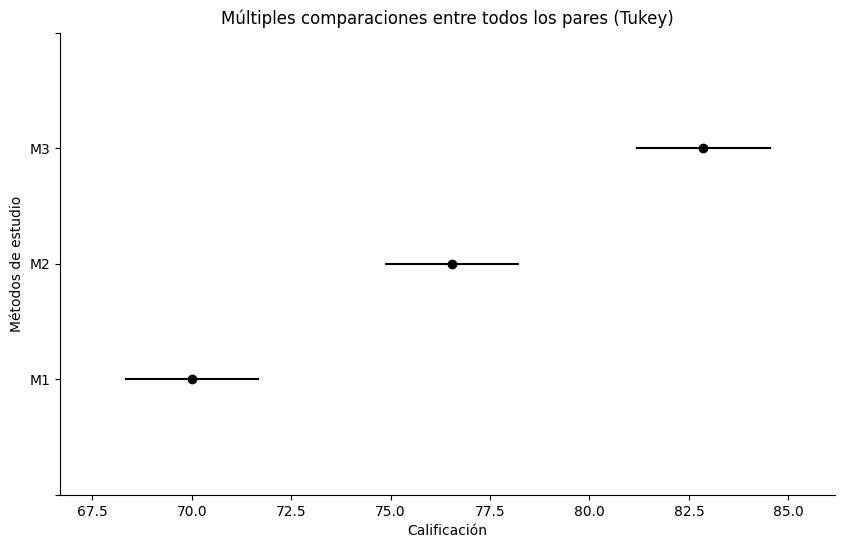

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['calificacion'], # Variable de respuesta
    groups=df['metodo'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Métodos de estudio", xlabel="Calificación")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

Con esto podemos ver que los tres muestran diferencias significativas entre sí, con lo que el método 3 da mejores resultados que el método 2 y el método 2 da mejores resultados que el método 1.

El test de Tukey da como resultado una tabla que tiene la siguente forma:

```
Multiple Comparison of Means - Tukey HSD, FWER=0.05
===================================================
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    M1     M2   6.5333 0.0001 3.1595  9.9072   True
    M1     M3  12.8667    0.0 9.4928 16.2405   True
    M2     M3   6.3333 0.0001 2.9595  9.7072   True
---------------------------------------------------

```

En la primera fila vemos:
```
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    M1     M2   6.5333 0.0001 3.1595  9.9072   True
```

El resultado indica que se compararon los grupos correspondientes al Método 1 (`M1`) y al Método 2 (`M2`). Se obtuvo una diferencia de medias de `6.5333`, lo que en este contexto implica que, en promedio, el Método 2 supera al Método 1 por `6.5333` puntos en la calificación.

El valor p asociado a esta comparación es `0.0001`, lo cual indica que la diferencia observada es estadísticamente significativa.

El intervalo de confianza al 95% para la diferencia de medias se encuentra entre `3.1595` y `9.072`, lo que sugiere que la ventaja del Método 2 sobre el Método 1 se mantiene positiva dentro de este rango.

Finalmente, en la columna `reject` se indica `True`, lo que confirma que se rechaza la hipótesis nula de igualdad de medias, concluyendo que existe una diferencia significativa entre ambos métodos.

El gráfico sólo proporciona una interpretación visual del test de Tukey.


### Supuestos

Cuando se realiza el ANOVA se hacen un par de supuestos:
+ Normalidad en los residuales
+ Homoscedasticidad en los residuales

Estos supuestos ya se han estudiado en regresión lineal. Si se cumplen, los resultados del ANOVA pueden interpretarse con confianza.

El supuesto de la normalidad lo manejamos tal cual hicimos en regresión lineal:

In [ ]:
residuales = modelo.resid

valor-p (Shapiro) = 0.2261506459747326


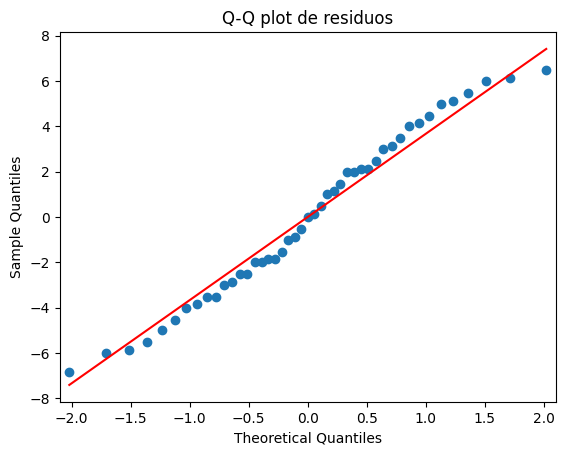

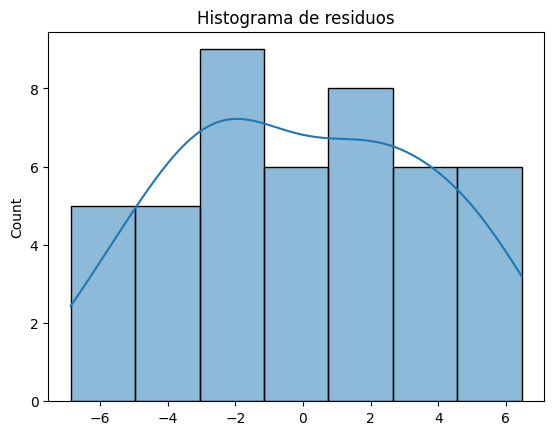

In [ ]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

Se pasa el test de Shapiro por lo que la normalidad puede asumirse.

Anteriormente usamos Breusch-Pagan para evaluar el supuesto de homoscedasticidad en los residuales. Sin embargo, en este contexto esto no aplica. En el contexto de ANOVA, lo que se desea evaluar es si las varianzas son iguales entre tratamientos (Levene), no si la varianza cambia en función de una variable continua (Breusch-Pagan). Por eso se hizo tanto enfasis en que, al menos una de las variables independientes tenía que ser continua.

El test de Levene está diseñado precisamente para comparar la dispersión entre tratamientos y determinar si puede asumirse la homoscedasticidad.

Para corto, Levene responde a la pregunta correcta en ANOVA (¿las varianzas son iguales entre tratamientos?), mientras que Breusch-Pagan responde a una pregunta distinta propia de modelos de regresión (¿las varianzas son iguales entre los distintos valores de X?).

El test de Levene lo aplicamos de la siguiente manera.

In [ ]:
from scipy.stats import levene

# Separar por grupos

# grupo_tal = df[df["categórica de interés"] == "cada uno de los valores categóricos"]["variable de respuesta"]
grupo_M1 = df[df['metodo'] == 'M1']['calificacion']
grupo_M2 = df[df['metodo'] == 'M2']['calificacion']
grupo_M3 = df[df['metodo'] == 'M3']['calificacion']

stat, p = levene(grupo_M1, grupo_M2, grupo_M3)

print(f"Estadístico de Levene: {stat:.4f}")
print(f"p-valor: {p:.4f}")

Estadístico de Levene: 0.0228
p-valor: 0.9775


La prueba de hipótesis del test de Levene es muy parecido a la del test de Breusch-Pagan:

+ $H_0$: Homoscedasticidad
+ $H_1$: Heteroscedasticidad

Aunque, quizá más propio de Levene, sería:

+ $H_0$: Los tratamientos tienen la misma varianza
+ $H_1$: Al menos un tratamiento tiene una varianza distinta

Pero si se busca formalidad, para tesis o artículo:

+ $H_0: \sigma_1^2 = \sigma_2^2 = \sigma_3^2$
+ $H_1$: Al menos una varianza es diferente

Por lo tanto, se cumple el supuesto de homogeneidad de varianzas, lo que permite confiar en los resultados del ANOVA.

Ante este escenario, surge una pregunta natural: ¿qué ocurre si alguno de los supuestos no se cumple? En ese caso, los resultados del ANOVA pueden perder confiabilidad, ya que las conclusiones dependen de dichos supuestos.

No obstante, el ANOVA es relativamente robusto a desviaciones moderadas de la normalidad, especialmente cuando el tamaño de muestra es grande. Sin embargo, es más sensible a la falta de homogeneidad de varianzas, lo cual puede afectar de manera más directa la validez de las inferencias.

En situaciones donde las desviaciones no son severas o las diferencias entre tratamientos son suficientemente grandes, el análisis puede seguir proporcionando resultados útiles. Aun así, es importante interpretar las conclusiones con cautela y, de ser necesario, considerar alternativas, como pruebas no paramétricas o transformaciones de los datos, mediante el método de Box-Cox, por ejemplo.


### Box-Cox

La transformación de Box-Cox es una técnica que se utiliza para transformar la variable de respuesta con el objetivo de mejorar el cumplimiento de los supuestos del modelo, especialmente la normalidad de los residuos y la homogeneidad de varianzas.

Consiste en aplicar una transformación de la forma:

$$
y^{(\lambda)} =
\begin{cases}
\frac{y^\lambda - 1}{\lambda}, & \lambda \neq 0 \\
\ln(y), & \lambda = 0
\end{cases}
$$

donde $\lambda$ es un parámetro que se estima a partir de los datos y que determina el tipo de transformación.

Dependiendo del valor de $\lambda$, la transformación puede corresponder a casos conocidos como:
- $\lambda = 1$: sin transformación  
- $\lambda = 0$: logaritmo  
- $\lambda = 0.5$: raíz cuadrada  

En esencia, Box-Cox busca “reexpresar” los datos para que se comporten de forma más adecuada para el análisis estadístico.

En el siguiente bloque de código se muestra la forma básica de aplicar una transformación a la variable de respuesta utilizando el método de Box-Cox. A partir de la variable original calificacion, se genera una nueva variable llamada `calificacion_boxcox`, que corresponde a la versión transformada.

Al ejecutar este procedimiento, también se obtiene el valor óptimo $\lambda$, el cual determina la transformación que mejor contribuye al cumplimiento de los supuestos del modelo.

Adicionalmente, se presenta un gráfico que relaciona la variable original con la variable transformada. Si los puntos siguen aproximadamente una línea recta, esto indica que la transformación fue leve o incluso innecesaria. En cambio, si se observa una curvatura pronunciada, significa que la transformación aplicada fue más significativa.

Lambda óptimo: 0.6657105440261948


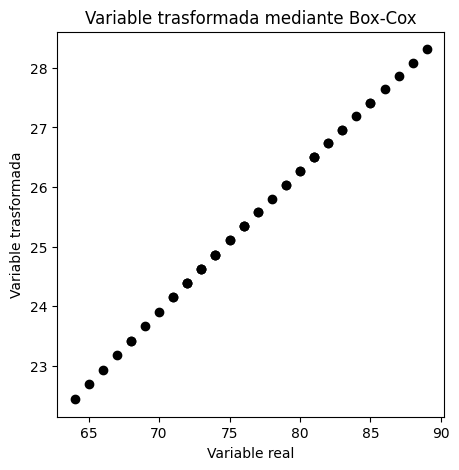

In [ ]:
# Si no se cumple el supuesto de normalidad o el de homoscedasticidad
from scipy.stats import boxcox
import matplotlib.pyplot as plt

# Transformación mediante el método box-cox
# Solo funciona si Y > 0

df["calificacion_boxcox"], lambda_opt = boxcox(df["calificacion"])
print(f"Lambda óptimo: {lambda_opt}")

plt.figure(figsize = (5, 5), dpi = 100)
plt.scatter(df["calificacion"], df["calificacion_boxcox"], color = "black")
plt.title("Variable trasformada mediante Box-Cox")
plt.xlabel("Variable real")
plt.ylabel("Variable trasformada")
plt.show()

El DataFrame queda de la siguiente manera:

In [ ]:
df

,grupo,metodo,calificacion,calificacion_boxcox
0,A,M1,64,22.436935
1,A,M1,66,22.932385
2,A,M1,65,22.685297
3,A,M1,67,23.178224
4,A,M1,68,23.422840
5,A,M2,71,24.149582
6,A,M2,72,24.389535
7,A,M2,73,24.628377
8,A,M2,74,24.866127
9,A,M2,73,24.628377


Una vez hecha esta trasformación, se sigue el mismo procedimiento, pero ahora usando como variable de respuesta la variable `calificacion_boxcox`:
+ ANOVA
+ test de normalidad
+ test de homoscedasticidad
+ test de Tukey

Sin embargo, es posible que, incluso después de aplicar una transformación, los supuestos del modelo no se cumplan. En estos casos, es necesario considerar métodos alternativos.

Si se incumplen simultáneamente los supuestos de normalidad y homogeneidad de varianzas, es recomendable recurrir a métodos no paramétricos. Por otro lado, si únicamente se incumple el supuesto de homocedasticidad, puede utilizarse un ANOVA con corrección de Welch, el cual es más robusto ante varianzas desiguales.

### Métodos no paramétricos

Los métodos no paramétricos son técnicas estadísticas que no requieren asumir una forma específica para la distribución de los datos, como la normalidad. En lugar de basarse directamente en los valores originales, estos métodos suelen trabajar con rangos o posiciones relativas de los datos.

Se utilizan principalmente cuando no se cumplen los supuestos de los métodos paramétricos, como la normalidad de los residuos o la homogeneidad de varianzas, o cuando los datos son de naturaleza ordinal o presentan valores atípicos que dificultan el análisis tradicional.

A pesar de su utilidad, los métodos no paramétricos suelen ser menos potentes que los paramétricos, es decir, tienen menor capacidad para detectar diferencias reales cuando estas existen. Por esta razón, siempre que se cumplan los supuestos, se prefieren los métodos paramétricos, ya que aprovechan mejor la información contenida en los datos y permiten obtener inferencias más precisas.

La prueba de Kruskal-Wallis es un método no paramétrico que se utiliza como alternativa al ANOVA cuando no se cumplen sus supuestos, particularmente la normalidad de los residuos o la homogeneidad de varianzas. Este método permite comparar tres o más grupos independientes para determinar si existen diferencias entre ellos.

A diferencia del ANOVA, que trabaja con los valores originales, la prueba de Kruskal-Wallis se basa en los rangos de los datos, lo que la hace más robusta frente a valores atípicos y distribuciones no normales.

En esencia, esta prueba evalúa si las distribuciones de los grupos son iguales o si al menos uno de ellos presenta un comportamiento diferente.

Hipótesis de la prueba de Kruskal-Wallis:

+ $H_0$: las distribuciones de todos los grupos son iguales
+ $H_1$: al menos una de las distribuciones es diferente

El código para realizar la prueba de Kruskal-Wallis se presenta a continuación:

In [ ]:
from scipy.stats import kruskal

# Separar las calificaciones por tratamiento
grupo_M1 = df[df["metodo"] == "M1"]["calificacion"]
grupo_M2 = df[df["metodo"] == "M2"]["calificacion"]
grupo_M3 = df[df["metodo"] == "M3"]["calificacion"]

# Prueba de Kruskal-Wallis
estadistico, valor_p = kruskal(grupo_M1, grupo_M2, grupo_M3)

print(f"Estadístico de Kruskal-Wallis: {estadistico:.4f}")
print(f"Valor-p: {valor_p:.4f}")

Estadístico de Kruskal-Wallis: 30.1382
Valor-p: 0.0000


Con este resultado se concluye que al menos uno de los métodos produce un cambio en las calificaciones. Sin embargo, la prueba de Kruskal–Wallis no permite identificar entre qué grupos se presentan estas diferencias, por lo que es necesario aplicar un análisis post hoc.

El equivalente no paramétrico del test de Tukey en este contexto es el test de Dunn, y una opción común es emplearlo con corrección de Bonferroni, con el fin de controlar el error tipo I al realizar múltiples comparaciones.

Hay un pequeño detalle digno de mención. La librería `scikit_posthocs`es necesaria para usar el test de Dunn, pero esta no está por default en colab, así que hay que instalarla manualmente, mediante el siguiente bloque. Esto sólo hay que hacerlo una vez.

In [ ]:
!pip install scikit-posthocs

Ahora sí podemos realizar el test de Dunn:

In [ ]:
import scikit_posthocs as sp

# Dunn test con corrección de Bonferroni
resultado = sp.posthoc_dunn(
    df,
    val_col="calificacion",
    group_col="metodo",
    p_adjust="bonferroni"
)

resultado.round(4)

,M1,M2,M3
M1,1.0000,0.0145,0.0000
M2,0.0145,1.0000,0.0227
M3,0.0000,0.0227,1.0000


La tabla resultante del test de Dunn presenta los valores p correspondientes a las comparaciones por pares entre los tratamientos.

Si el valor p es menor que el nivel de significancia $(\alpha = 0.05)$, se concluye que existe una diferencia significativa entre los grupos comparados.

En este caso, todas las comparaciones presentan valores p menores a 0.05, lo que indica que todos los métodos difieren significativamente entre sí.

Es importante señalar que esta prueba únicamente indica la existencia de diferencias, pero no su dirección. Para ello, es necesario analizar las medianas o medias de cada grupo.

En este punto, el gráfico de Tukey puede utilizarse únicamente como referencia para visualizar el orden relativo entre los tratamientos (qué método presenta valores mayores o menores). Sin embargo, las conclusiones sobre diferencias significativas deben basarse exclusivamente en los resultados del test de Dunn.

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
    M1     M2   6.5333 0.0001 3.1595  9.9072   True
    M1     M3  12.8667    0.0 9.4928 16.2405   True
    M2     M3   6.3333 0.0001 2.9595  9.7072   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

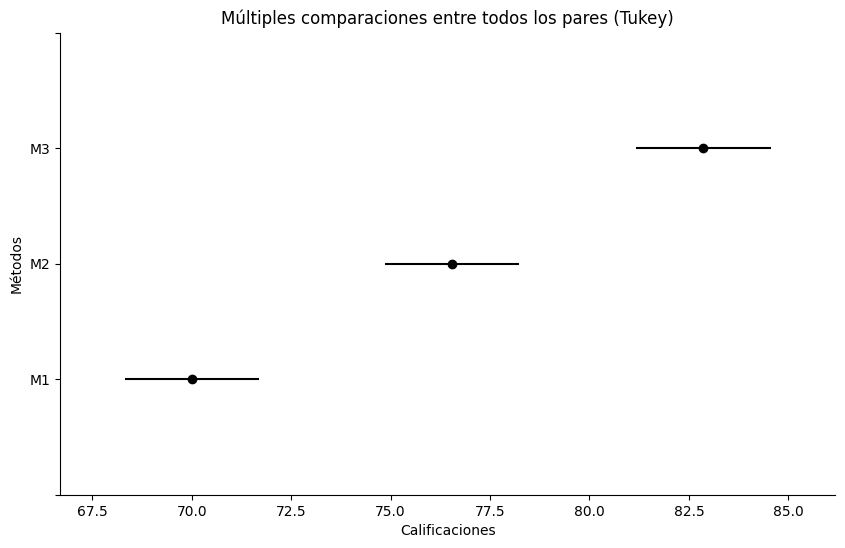

In [ ]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['calificacion'], # Variable de respuesta
    groups=df['metodo'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Métodos", xlabel="Calificaciones")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

## Diseño en Bloques Completos al Azar (DBCA)

No obstante, es importante señalar que los datos fueron obtenidos bajo un Diseño en Bloques Completos al Azar (DBCA), lo cual introduce una estructura adicional en el experimento que debe ser considerada en el análisis.

Volvamos a repasar el problema:

Se desea evaluar el efecto de distintos métodos de estudio sobre el desempeño académico de los estudiantes en un curso. En particular, se comparan tres estrategias de preparación para un examen:

+ Método 1: estudio tradicional basado en apuntes y lectura teórica,
+ Método 2: estudio apoyado en guías de ejercicios resueltos,
+ Método 3: estudio con guías de ejercicios y evaluaciones cortas de retroalimentación.

Para la realización del experimento, se seleccionaron 15 estudiantes de cada uno de los tres grupos académicos (A, B y C), obteniendo un total de 45 participantes.

Vamos a dar más contexto para entender este diseño.

Se cuenta con tres grupos de estudiantes: A, B y C. Una alternativa aparentemente más sencilla habría sido asignar el Método 1 al grupo A, el Método 2 al grupo B y el Método 3 al grupo C. Sin embargo, este enfoque presenta un problema fundamental: no permitiría distinguir si las diferencias observadas se deben al método de estudio o a las características propias de cada grupo.

Por ejemplo, si el grupo C tuviera un mejor desempeño académico en general, cualquier método aplicado a ese grupo podría mostrar resultados superiores, independientemente de su efectividad real. En ese caso, no sería posible atribuir correctamente el efecto al tratamiento.

Para evitar este problema, el investigador aplica todos los métodos en cada grupo. De esta manera, cada grupo funciona como una referencia interna, permitiendo comparar los métodos bajo condiciones similares. Así, si un grupo presenta un mejor nivel general, este efecto se distribuye entre todos los tratamientos y no sesga la comparación entre ellos.

En consecuencia, se logra controlar la variabilidad asociada al factor “grupo”, lo cual es precisamente el objetivo del Diseño en Bloques Completos al Azar (DBCA).

Idealmente, se preferiría trabajar bajo un Diseño Completamente al Azar (DCA), donde todas las unidades experimentales sean homogéneas. Sin embargo, en la práctica esto rara vez es posible. En este caso, por ejemplo, resultaría difícil disponer de un conjunto de estudiantes completamente homogéneo, en el que la única fuente de variación fuera el método de estudio. Por ello, el uso de bloques se convierte en una estrategia necesaria y realista para mejorar la calidad del análisis.

**El diseño de experimentos es más importante en la planificación que en el análisis. Un buen diseño simplifica el análisis de resultados; un mal diseño puede volverlo impracticable.**

Si el investigador hubiera asignado cada método a un grupo distinto, habría comprometido la validez de la experimentación. En cambio, gracias a la planificación adoptada, fue posible obtener una estructura de datos adecuada para el análisis. De hecho, incluso al tratar la base de datos como un Diseño Completamente al Azar (DCA), se logra un análisis razonable. Sin embargo, al considerar correctamente la estructura en bloques, es posible obtener conclusiones más precisas y confiables.

En un Diseño en Bloques Completos al Azar (DBCA) se consideran tres elementos fundamentales:

+ factor de interés: variable categórica cuyos efectos se desean evaluar,
+ al menos un factor de bloqueo: variable categórica que no es de interés principal, pero que puede influir en la respuesta,
+ y la variable de respuesta, que es la medida utilizada para comparar los efectos de los tratamientos.

En este caso, el factor es el método de preparación, el factor de bloque es el grupo (No nos interesa saber qué grupo es mejor, solo nos interesa medir el efecto de cada método), y la variable de respuesta son las calificaciones.

Ya tenemos la base de datos con esa estructura:

In [ ]:
df

El ANOVA se realiza de la siguiente manera:

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Hipótesis:
# H0: mu_1 = mu_2 = mu_3
# H1: al menos una media es diferente

modelo = ols('calificacion ~ C(metodo) + C(grupo)', data=df).fit()

tabla_anova = sm.stats.anova_lm(modelo, typ=2)

tabla_anova.round(4) # round(4) es para redondear a 4 decimales.

Se observa que el valor-p, tanto para el factor “Método” como para el factor de bloqueo “Grupo”, es igual a cero a cuatro decimales. Esto indica que existen diferencias significativas no solo entre los métodos, sino también entre los grupos.

Este resultado confirma que la inclusión del factor de bloqueo estuvo plenamente justificada. De haberse utilizado un Diseño Completamente al Azar (DCA), ignorando las posibles diferencias entre grupos, se habría incorporado una fuente adicional de variabilidad al error, lo que podría haber afectado la precisión y validez de las conclusiones del experimento.

A partir de este punto, el análisis sigue el mismo procedimiento descrito anteriormente: se aplica la prueba de Tukey de la misma manera y se verifican los supuestos bajo los mismos criterios.

Esto refuerza una idea fundamental: en diseño de experimentos, la diferencia clave no radica en el análisis, sino en la planificación del experimento. Un diseño adecuado permite aplicar herramientas estándar de análisis de forma directa, mientras que un diseño deficiente puede dificultar o incluso invalidar la interpretación de los resultados.

## Cuadro Latino

Aunque ya se ha establecido que el DBCA es adecuado para el problema planteado, aún queda un aspecto importante por considerar. Podría surgir la siguiente pregunta: ¿quién fue el encargado de enseñar a los estudiantes cada método de estudio?

La respuesta a esta pregunta no es trivial. Si los investigadores hubieran asignado la implementación de todos los métodos a un solo profesor, podría introducirse un sesgo asociado a sus preferencias, experiencia o afinidad con alguno de los métodos. En ese caso, las diferencias observadas podrían deberse, al menos en parte, al profesor y no exclusivamente al método de estudio.

Para mitigar esta posible fuente de variabilidad, los investigadores podrían incorporar un segundo factor de bloqueo, por ejemplo, considerando distintos profesores. De esta manera, cada método sería aplicado por diferentes profesores bajo una estructura controlada, reduciendo el sesgo y permitiendo aislar mejor el efecto del tratamiento.

Dado que ya estan familiarizados con este problema, vamos a expandirlo. Vamos a suponer que este sesgo potencial motivo a otro grupo de investigadores a expandir la experimentación considerando la variabilidad aportada por el profesor, con lo que se obtuvo lo siguiente:

| Grupo / Profesor | P1 | P2 | P3 |
|---|---|---|---|
| A | M1 = 65, 64 | M2 = 74, 75 | M3 = 81, 82 |
| B | M2 = 76, 74 | M3 = 81, 83 | M1 = 71, 73 |
| C | M3 = 86, 88 | M1 = 72, 74 | M2 = 81, 84 |

